# Precursor-selection strategies vs. the full run

Compares the `precursor_ppm`/`precursor_mz` cloud of a full, **truly unfiltered** SAGE run
against the three precursor-selection strategies available for the recalibration branch's
calibration-only pass (`timstofu.precursor_selection`): `top_k_intense` (naive top-K),
`local_intensity_maxima_on_clusters` ("non_overlap", grid-binned NMS), and
`local_intensity_maxima_via_box_nms` ("argmax_nms", true per-point box-centered NMS,
mimicking `find_ms1_argmaxes`'s scale-estimation sieve).

**Reference ("full") data comes from `jobs/short_test.toml`**, whose `mkpmsms` precursor
filter has no effective limit (`LIMIT 4000000` against a run that only ever produces
~649,060 `tof_filtered_precursors`) -- this is the true unfiltered population, not
`jobs/quick_test_10k.toml`'s own 10,000-precursor-capped pool. The three strategies
themselves are still drawn from `jobs/quick_test_10k_recal_grid.toml`'s 10,000-precursor
pool (run as one `__grid`-expanded job so the three share a cached upstream DAG) -- so this
notebook is really asking "how well does a strategy applied to a pre-filtered 10k pool
recover the shape of the *true* full population," not just "how well does it recover its
own pool's shape."

In [1]:
import os
import subprocess
from pathlib import Path

# Notebook lives 3 levels under the repo root; jupyter/nbconvert default the kernel's cwd
# to the notebook's own directory, so resolve REPO_ROOT and chdir into it *before*
# importing searchops.recalibration below -- that module's dev/inspection block runs a
# cwd-relative file read at import time, which needs cwd == repo root to succeed.
REPO_ROOT = (Path.cwd() / "../../..").resolve()
os.chdir(REPO_ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from searchops.recalibration import filter_top_psms

FDR = 0.01

# Fixed categorical order (Okabe-Ito, colorblind-safe) -- color follows the entity
# (strategy), never rank, and stays consistent across every panel below.
COLORS = {
    "full": "#0072B2",
    "top_k_intense": "#E69F00",
    "non_overlap": "#D55E00",
    "argmax_nms": "#009E73",
}

# Display labels for plots/tables -- top_k_intense's k is fixed at 5000 in
# jobs/quick_test_10k_recal_grid.toml, so show the actual value rather than the
# generic parameter name.
LABELS = {
    "full": "full",
    "top_k_intense": "top_5000_intense",
    "non_overlap": "non_overlap",
    "argmax_nms": "argmax_nms",
}

## Resolve result paths via `./nf outputs` (not hardcoded node hashes)

Node hashes change if any upstream config/code changes, so paths are re-resolved from the
job TOMLs each time this notebook runs rather than pasted in as literals.

In [2]:
def nf_outputs(job_toml: str) -> dict[str, dict[str, str]]:
    """Parse `./nf outputs <job_toml>` into {combo_label: {output_name: result_path}}."""
    proc = subprocess.run(
        ["./nf", "outputs", job_toml],
        cwd=REPO_ROOT, capture_output=True, text=True, check=True,
    )
    combos: dict[str, dict[str, str]] = {}
    label = None
    for line in proc.stdout.splitlines():
        if not line.strip():
            continue
        if line.startswith("[") and line.endswith("]"):
            label = line[1:-1]
            combos[label] = {}
            continue
        key, rest = line.split("\t", 1)
        fields = dict(part.split("=", 1) for part in rest.split("\t"))
        combos[label][key] = fields["result"]
    return combos


def find_combo(combos: dict[str, dict[str, str]], contains: str) -> dict[str, str]:
    matches = [label for label in combos if contains in label]
    assert len(matches) == 1, f"expected exactly one combo containing {contains!r}, got {matches}"
    return combos[matches[0]]


# short_test.toml is the true unfiltered population (~649,060 tof_filtered_precursors);
# the three strategies below are still drawn from quick_test_10k_recal_grid's 10,000-capped pool.
baseline = nf_outputs("jobs/short_test.toml")["short_test"]
grid = nf_outputs("jobs/quick_test_10k_recal_grid.toml")

paths = {
    "full": REPO_ROOT / baseline["sage_results_tsv"],
    "top_k_intense": REPO_ROOT / find_combo(grid, "top_k_intense")["filtered_sage_results_tsv"],
    "non_overlap": REPO_ROOT / find_combo(grid, "non_overlap")["filtered_sage_results_tsv"],
    "argmax_nms": REPO_ROOT / find_combo(grid, "argmax_nms")["filtered_sage_results_tsv"],
}
paths

{'full': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/short_test/sage_results_tsv/results.sage.tsv'),
 'top_k_intense': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+top_k_intense/filtered_sage_results_tsv/results.sage.tsv'),
 'non_overlap': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+non_overlap/filtered_sage_results_tsv/results.sage.tsv'),
 'argmax_nms': PosixPath('/home/matteo/Projects/ionmaiden/pipelines/necromerge2/results/quick_test_10k_recal_grid__recalibration_precursor_selection+argmax_nms/filtered_sage_results_tsv/results.sage.tsv')}

## Load confident PSMs from each run

`filter_top_psms` (already used by `recalibrate()`) handles the `rank==1 & peptide_q<=fdr`
filter and adds the `precursor_mz` column.

In [3]:
dfs = []
for strategy, path in paths.items():
    df = filter_top_psms(path, fdr=FDR)
    df["strategy"] = strategy
    dfs.append(df)
all_df = pd.concat(dfs, ignore_index=True)

full_df = all_df[all_df["strategy"] == "full"]

In [4]:
all_df.groupby("strategy").agg(
    n=("precursor_ppm", "size"),
    precursor_ppm_median=("precursor_ppm", "median"),
    precursor_ppm_min=("precursor_ppm", "min"),
    precursor_ppm_max=("precursor_ppm", "max"),
    fragment_ppm_median=("fragment_ppm", "median"),
).reindex(["full", "top_k_intense", "non_overlap", "argmax_nms"]).rename(index=LABELS)

,n,precursor_ppm_median,precursor_ppm_min,precursor_ppm_max,fragment_ppm_median
strategy,,,,,
full,78255,-4.412877,-12.082839,12.057150,5.075089
top_5000_intense,3920,-3.939544,-12.050043,10.738251,4.223203
non_overlap,678,-3.359096,-11.742198,9.105439,4.633556
argmax_nms,623,-3.448421,-11.730722,11.613807,4.718801


## Main panel: the full run's ppm-error cloud

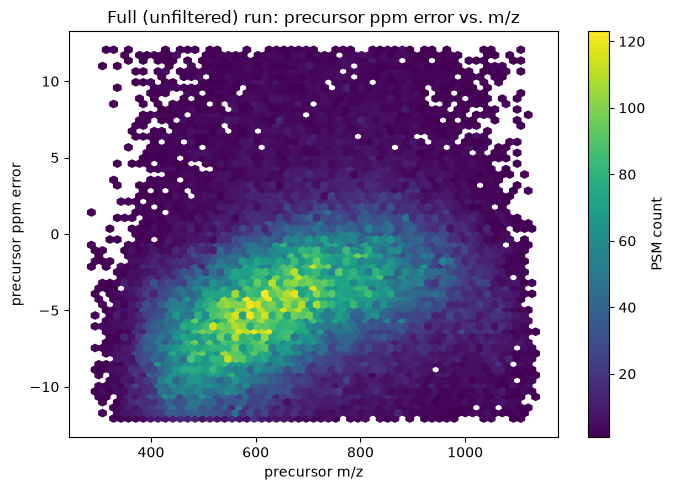

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
hb = ax.hexbin(
    full_df["precursor_mz"], full_df["precursor_ppm"],
    gridsize=60, cmap="viridis", mincnt=1,
)
ax.set_xlabel("precursor m/z")
ax.set_ylabel("precursor ppm error")
ax.set_title("Full (unfiltered) run: precursor ppm error vs. m/z")
fig.colorbar(hb, ax=ax, label="PSM count")
fig.tight_layout()
plt.show()

## Other ways to probe the same cloud

Each strategy's selected points overlaid on the full run's density (same reference density
repeated in each panel so the comparison is apples-to-apples), plus a normalized marginal
`precursor_ppm` histogram with all four series -- independent of the 2D view, and not
affected by the very different sample sizes since each is density-normalized.

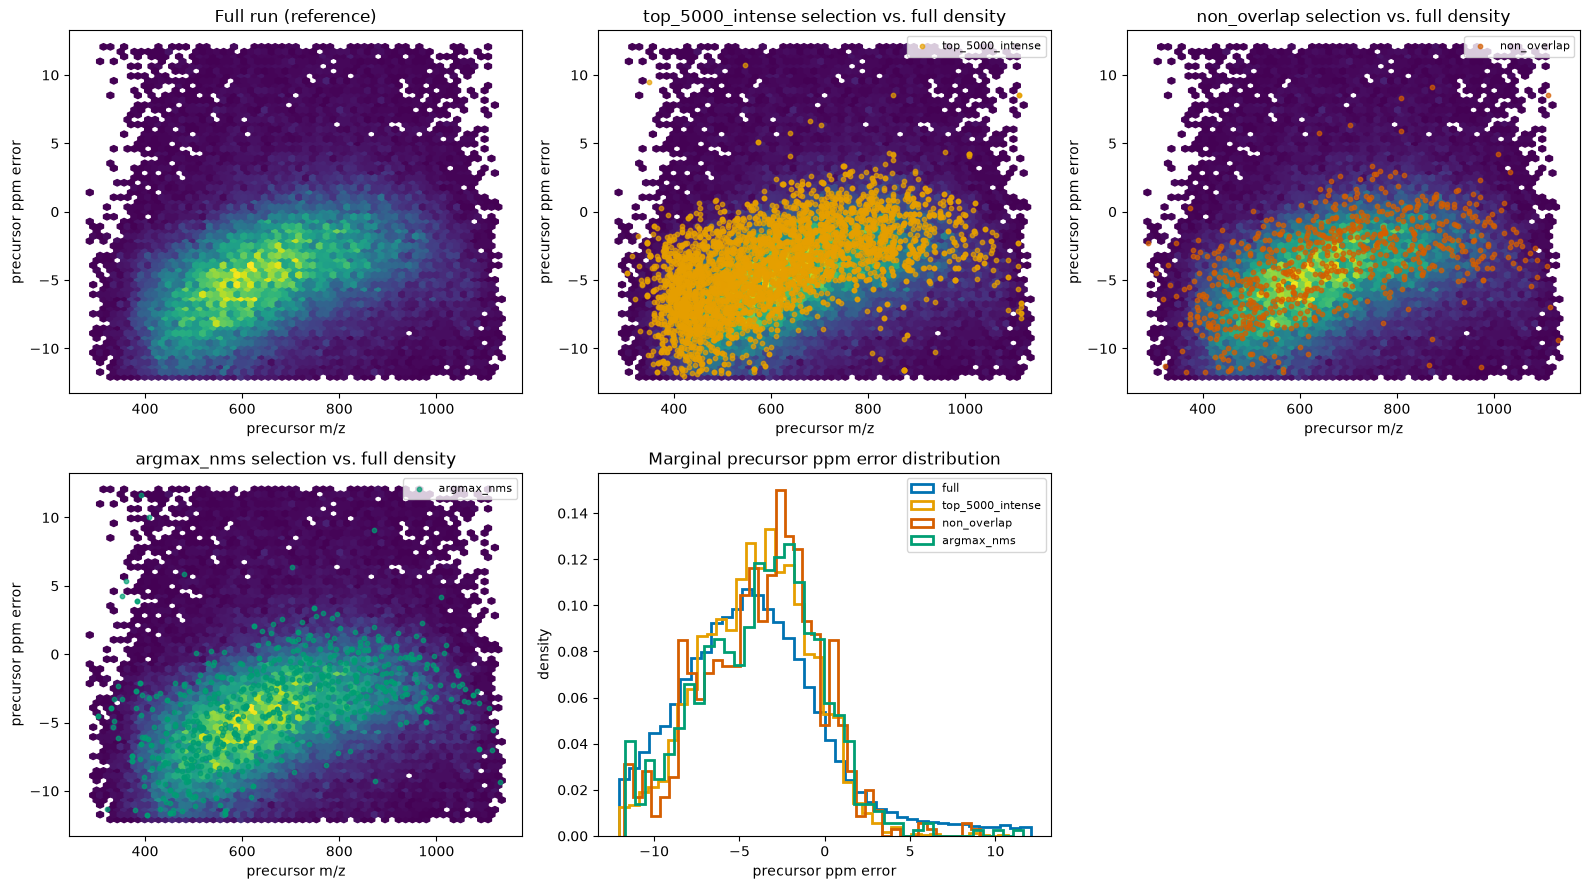

In [6]:
def plot_density(ax, df, title):
    hb = ax.hexbin(
        df["precursor_mz"], df["precursor_ppm"], gridsize=60, cmap="viridis", mincnt=1,
    )
    ax.set_title(title)
    ax.set_xlabel("precursor m/z")
    ax.set_ylabel("precursor ppm error")
    return hb


fig, axes = plt.subplots(2, 3, figsize=(16, 9))

plot_density(axes[0, 0], full_df, "Full run (reference)")

overlay_axes = {
    "top_k_intense": axes[0, 1],
    "non_overlap": axes[0, 2],
    "argmax_nms": axes[1, 0],
}
for strategy, ax in overlay_axes.items():
    plot_density(ax, full_df, f"{LABELS[strategy]} selection vs. full density")
    sub = all_df[all_df["strategy"] == strategy]
    ax.scatter(
        sub["precursor_mz"], sub["precursor_ppm"],
        s=10, color=COLORS[strategy], alpha=0.7, label=LABELS[strategy],
    )
    ax.legend(loc="upper right", fontsize=8)

ax_hist = axes[1, 1]
for strategy in ["full", "top_k_intense", "non_overlap", "argmax_nms"]:
    sub = all_df[all_df["strategy"] == strategy]
    ax_hist.hist(
        sub["precursor_ppm"], bins=40, density=True, histtype="step",
        linewidth=2, label=LABELS[strategy], color=COLORS[strategy],
    )
ax_hist.set_xlabel("precursor ppm error")
ax_hist.set_ylabel("density")
ax_hist.set_title("Marginal precursor ppm error distribution")
ax_hist.legend(fontsize=8)

axes[1, 2].axis("off")

fig.tight_layout()
plt.show()

## 2D KDE contour comparison

One panel per strategy. The full run's KDE is computed once outside the loop and
its contour (grey, reference) is reused unchanged in every panel -- no per-panel
recompute, no hexbin stand-in -- with that strategy's own KDE contour drawn on
top of it in its own colour.

Each panel also overplots the actual `fit_correction()` curve (same
`[recalibration]` config as `quick_test_10k_recal_grid.toml`) fitted from that
strategy's own confident PSMs -- dashed, same colour as its KDE contour -- next
to the full run's own correction curve (grey dashed), so the plot shows not just
where the density sits but what each strategy's fitted recalibration would
actually do.


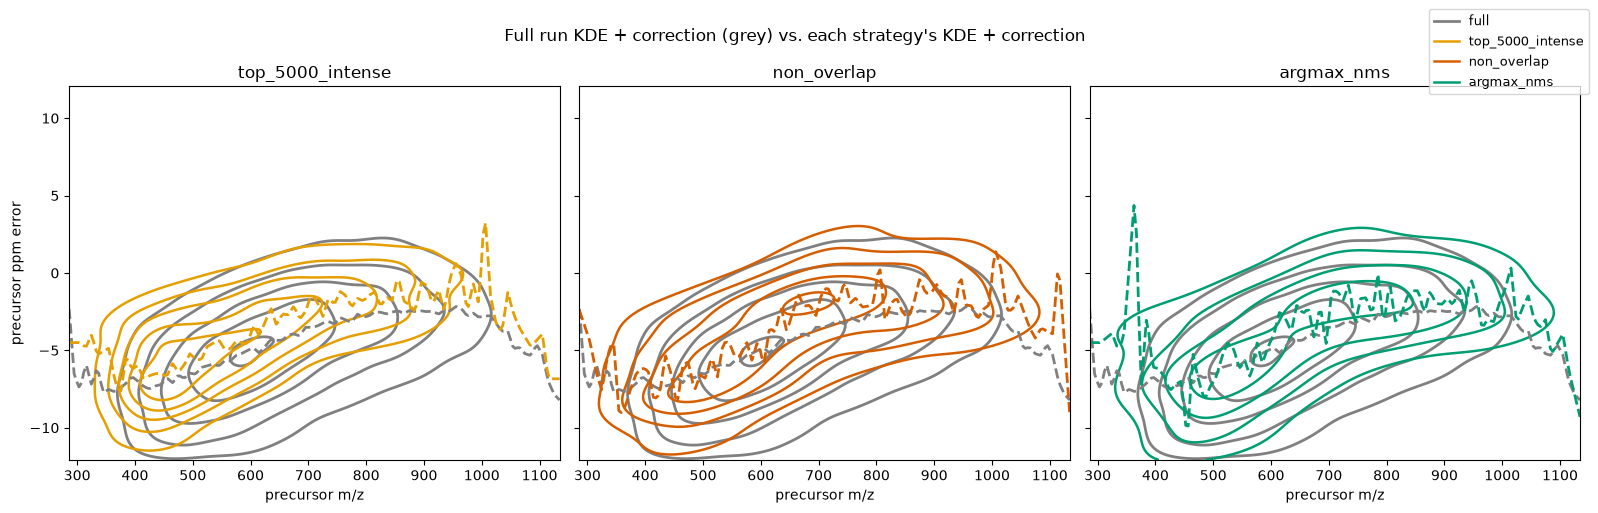

In [7]:
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

from searchops.recalibration import fit_correction

REFERENCE_COLOR = "#808080"

# Same recalibration config as jobs/quick_test_10k_recal_grid.toml's [recalibration],
# applied uniformly to every strategy's (and the full run's) own confident PSMs.
RECAL_CONFIG = {"model": "binned_median", "bin_width_da": 10.0}

x_min, x_max = all_df["precursor_mz"].min(), all_df["precursor_mz"].max()
y_min, y_max = all_df["precursor_ppm"].min(), all_df["precursor_ppm"].max()
xx, yy = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()])
mz_line = np.linspace(x_min, x_max, 200)


def kde_on_grid(df):
    kde = gaussian_kde(np.vstack([df["precursor_mz"], df["precursor_ppm"]]))
    return kde(grid_coords).reshape(xx.shape)


full_zz = kde_on_grid(full_df)  # computed once, reused in every panel below
full_correction = fit_correction(full_df, RECAL_CONFIG)

strategies = ["top_k_intense", "non_overlap", "argmax_nms"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)
for ax, strategy in zip(axes, strategies):
    ax.contour(xx, yy, full_zz, levels=5, colors=REFERENCE_COLOR, linewidths=2)
    sub = all_df[all_df["strategy"] == strategy]
    zz = kde_on_grid(sub)
    ax.contour(xx, yy, zz, levels=5, colors=COLORS[strategy], linewidths=1.8)

    correction = fit_correction(sub, RECAL_CONFIG)
    ax.plot(mz_line, full_correction(mz_line), color=REFERENCE_COLOR, linestyle="--", linewidth=2)
    ax.plot(mz_line, correction(mz_line), color=COLORS[strategy], linestyle="--", linewidth=2)

    ax.set_title(LABELS[strategy])
    ax.set_xlabel("precursor m/z")

axes[0].set_ylabel("precursor ppm error")
fig.suptitle("Full run KDE + correction (grey) vs. each strategy's KDE + correction")
fig.legend(
    handles=[Line2D([0], [0], color=REFERENCE_COLOR, lw=2, label="full")]
    + [Line2D([0], [0], color=COLORS[s], lw=1.8, label=LABELS[s]) for s in strategies],
    fontsize=9, loc="upper right", bbox_to_anchor=(1.0, 1.03),
)
fig.tight_layout()
plt.show()


## Quantifying the distributional gap: Wasserstein distance

A single number per strategy, complementing the marginal-histogram panel above:
the 1D Wasserstein (earth-mover's) distance between each strategy's `precursor_ppm`/
`fragment_ppm` distribution and the full run's -- smaller means the strategy's sampled
ppm-error distribution is a closer match to the true population's, independent of the very
different sample sizes.

In [8]:
from scipy.stats import wasserstein_distance

wasserstein_rows = []
for strategy in ["top_k_intense", "non_overlap", "argmax_nms"]:
    sub = all_df[all_df["strategy"] == strategy]
    wasserstein_rows.append(
        {
            "strategy": strategy,
            "wasserstein_precursor_ppm": wasserstein_distance(
                full_df["precursor_ppm"], sub["precursor_ppm"],
            ),
            "wasserstein_fragment_ppm": wasserstein_distance(
                full_df["fragment_ppm"], sub["fragment_ppm"],
            ),
        }
    )
pd.DataFrame(wasserstein_rows).set_index("strategy")

,wasserstein_precursor_ppm,wasserstein_fragment_ppm
strategy,,
top_k_intense,0.839731,0.980099
non_overlap,0.950990,0.578299
argmax_nms,0.796562,0.459591


## What to look for

- If `top_k_intense`'s points cluster tightly in one m/z/RT region while `non_overlap`/
  `argmax_nms` spread more evenly across the full density, that's the sampling bias the
  binned-median recalibration fit is exposed to when using the naive top-K strategy.
- `non_overlap` (grid-binned NMS) and `argmax_nms` (true per-point box-centered NMS) are
  both "spatially diverse" strategies but algorithmically different -- worth checking
  whether they actually select similar points despite the different mechanism, or diverge
  meaningfully (e.g. near grid-bin edges, where `non_overlap` can behave differently than a
  true per-point NMS).